### Connection Code

In [1]:
import os
from dotenv import load_dotenv
from databricks import sql

load_dotenv()

HOST = os.getenv("DATABRICKS_SERVER_HOSTNAME")
HTTP_PATH = os.getenv("DATABRICKS_HTTP_PATH")

if not HOST:
    raise ValueError("DATABRICKS_SERVER_HOSTNAME is missing")

if not HTTP_PATH:
    raise ValueError("DATABRICKS_HTTP_PATH is missing")

def get_connection():
    return sql.connect(
        server_hostname=HOST,
        http_path=HTTP_PATH,
        auth_type="databricks-oauth",
        user_agent_entry="zomato-market-expansion-eda"
    )

### Testing Connection

In [2]:
with get_connection() as conn:
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT
                current_timestamp() AS connected_at
        """)

        result = cursor.fetchall()

print(result)

[Row(connected_at=datetime.datetime(2026, 8, 11, 6, 15, 47, 466496, tzinfo=<StaticTzInfo 'Etc/UTC'>))]


### Building a reusable SQL -> Pandas Function

In [3]:
import pandas as pd


def query_df(query: str) -> pd.DataFrame:
    """
    Execute SQL against Databricks SQL Warehouse
    and return the result as a Pandas DataFrame.
    """

    with get_connection() as conn:
        with conn.cursor() as cursor:

            cursor.execute(query)

            rows = cursor.fetchall()

            columns = [
                description[0]
                for description in cursor.description
            ]

    return pd.DataFrame(rows, columns=columns)

#### Testing

In [4]:
test_df = query_df("""
SELECT
    1 AS test_value
""")

print(test_df)

   test_value
0           1


#### Defining Our Warehouse Objects

In [5]:
WAREHOUSE = "zomato_market_intelligence"

BRONZE = (
    f"{WAREHOUSE}."
    "bronze.stg_zomato_restaurant_items"
)

FACT_RESTAURANT = (
    f"{WAREHOUSE}."
    "silver.fact_restaurant"
)

FACT_MENU = (
    f"{WAREHOUSE}."
    "silver.fact_menu_item"
)

DIM_CITY = (
    f"{WAREHOUSE}."
    "silver.dim_city"
)

DIM_LOCALITY = (
    f"{WAREHOUSE}."
    "silver.dim_locality"
)

DIM_CUISINE = (
    f"{WAREHOUSE}."
    "silver.dim_cuisine"
)

DIM_MENU = (
    f"{WAREHOUSE}."
    "silver.dim_menu_item"
)

DIM_PRICE = (
    f"{WAREHOUSE}."
    "silver.dim_price_band"
)

BRIDGE_CUISINE = (
    f"{WAREHOUSE}."
    "silver.bridge_restaurant_cuisine"
)

GOLD_CITY = (
    f"{WAREHOUSE}."
    "gold.vw_city_performance"
)

GOLD_LOCALITY = (
    f"{WAREHOUSE}."
    "gold.vw_locality_performance"
)

GOLD_CUISINE = (
    f"{WAREHOUSE}."
    "gold.vw_cuisine_opportunity"
)

GOLD_PRICE = (
    f"{WAREHOUSE}."
    "gold.vw_pricing_analysis"
)

GOLD_EXPANSION = (
    f"{WAREHOUSE}."
    "gold.vw_expansion_opportunity"
)

#### Verifying all warehouse objects

In [6]:
objects = {
    "Bronze": BRONZE,
    "Restaurant Fact": FACT_RESTAURANT,
    "Menu Fact": FACT_MENU,
    "City View": GOLD_CITY,
    "Locality View": GOLD_LOCALITY,
    "Cuisine View": GOLD_CUISINE,
    "Pricing View": GOLD_PRICE,
    "Expansion View": GOLD_EXPANSION
}

for name, table in objects.items():

    query = f"""
    SELECT COUNT(*) AS row_count
    FROM {table}
    """

    result = query_df(query)

    print(
        f"{name:20s}: "
        f"{int(result.iloc[0]['row_count']):,} rows"
    )

Bronze              : 101,530 rows
Restaurant Fact     : 914 rows
Menu Fact           : 101,529 rows
City View           : 17 rows
Locality View       : 329 rows
Cuisine View        : 48 rows
Pricing View        : 4 rows
Expansion View      : 329 rows


### Creating Output Directory

In [7]:
from pathlib import Path

OUTPUT_DIR = Path("outputs/eda")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Output directory:",
    OUTPUT_DIR.resolve()
)

Output directory: E:\Data Science Study\Project\Data Analyst\Zomato\Advanced Data Analysis\notebooks\outputs\eda


### Importing Visualization Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### A - Data Quality EDA

#### 1. Missing-value Analysis

In [9]:
quality_columns = [
    "restaurant_key",
    "restaurant_name",
    "city",
    "locality",
    "cuisine",
    "dining_rating",
    "delivery_rating",
    "dining_votes",
    "delivery_votes",
    "item_name",
    "item_price",
    "item_votes",
    "best_seller_category",
    "dietary_tag",
    "platform_flag",
    "expansion_opportunity_score",
    "market_saturation_score"
]

In [ ]:
missing_expression = ",\n".join(
    [
        f"""
        SUM(
            CASE
                WHEN {column} IS NULL
                THEN 1
                ELSE 0
            END
        ) AS {column}_missing
        """
        for column in quality_columns
    ]
)

query = f"""
SELECT
    COUNT(*) AS total_rows,
    {missing_expression}
FROM {BRONZE}
"""

missing_raw = query_df(query)

missing_raw

,total_rows,restaurant_key_missing,restaurant_name_missing,city_missing,locality_missing,cuisine_missing,dining_rating_missing,delivery_rating_missing,dining_votes_missing,delivery_votes_missing,item_name_missing,item_price_missing,item_votes_missing,best_seller_category_missing,dietary_tag_missing,platform_flag_missing,expansion_opportunity_score_missing,market_saturation_score_missing
0,101530,0,0,0,0,0,26958,1244,0,0,1,0,0,0,101466,99223,0,0


In [ ]:
total_rows = int(
    missing_raw.iloc[0]["total_rows"]
)

missing_rows = []

for column in quality_columns:

    missing_count = int(
        missing_raw.iloc[0][
            f"{column}_missing"
        ]
    )

    missing_pct = (
        missing_count / total_rows
    ) * 100

    missing_rows.append(
        {
            "column": column,
            "missing_count": missing_count,
            "missing_pct": missing_pct
        }
    )

missing_summary = (
    pd.DataFrame(missing_rows)
    .sort_values(
        "missing_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

display(missing_summary)

,column,missing_count,missing_pct
0,dietary_tag,101466,99.936964
1,platform_flag,99223,97.727765
2,dining_rating,26958,26.551758
3,delivery_rating,1244,1.225254
4,item_name,1,0.000985
5,restaurant_key,0,0.000000
6,item_price,0,0.000000
7,expansion_opportunity_score,0,0.000000
8,best_seller_category,0,0.000000
9,item_votes,0,0.000000


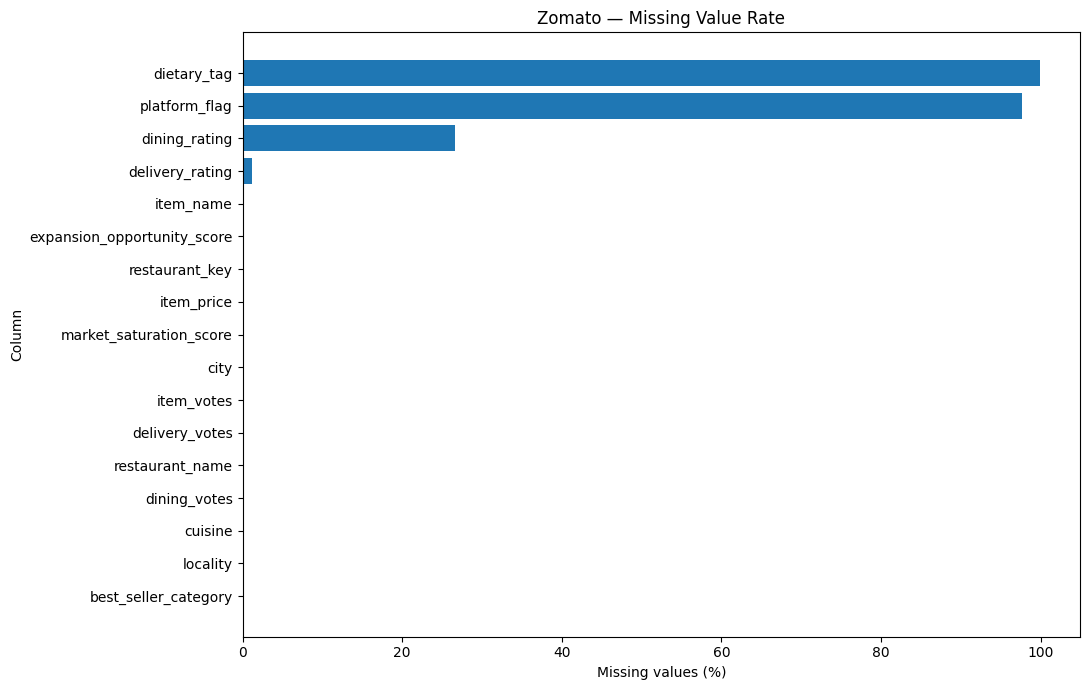

In [ ]:
## Missing-value bar chart

plot_df = (
    missing_summary
    .sort_values(
        "missing_pct",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_df["column"],
    plot_df["missing_pct"]
)

ax.set_xlabel(
    "Missing values (%)"
)

ax.set_ylabel(
    "Column"
)

ax.set_title(
    "Zomato — Missing Value Rate"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "01_missing_value_bar.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## Missing-value Heatmap

query = f"""
SELECT
    dining_rating,
    delivery_rating,
    dining_votes,
    delivery_votes,
    item_price,
    item_votes,
    best_seller_category,
    dietary_tag,
    platform_flag,
    expansion_opportunity_score,
    market_saturation_score
FROM {BRONZE}
LIMIT 500
"""

quality_sample = query_df(query)

In [ ]:
missing_matrix = (
    quality_sample
    .isna()
    .astype(int)
)

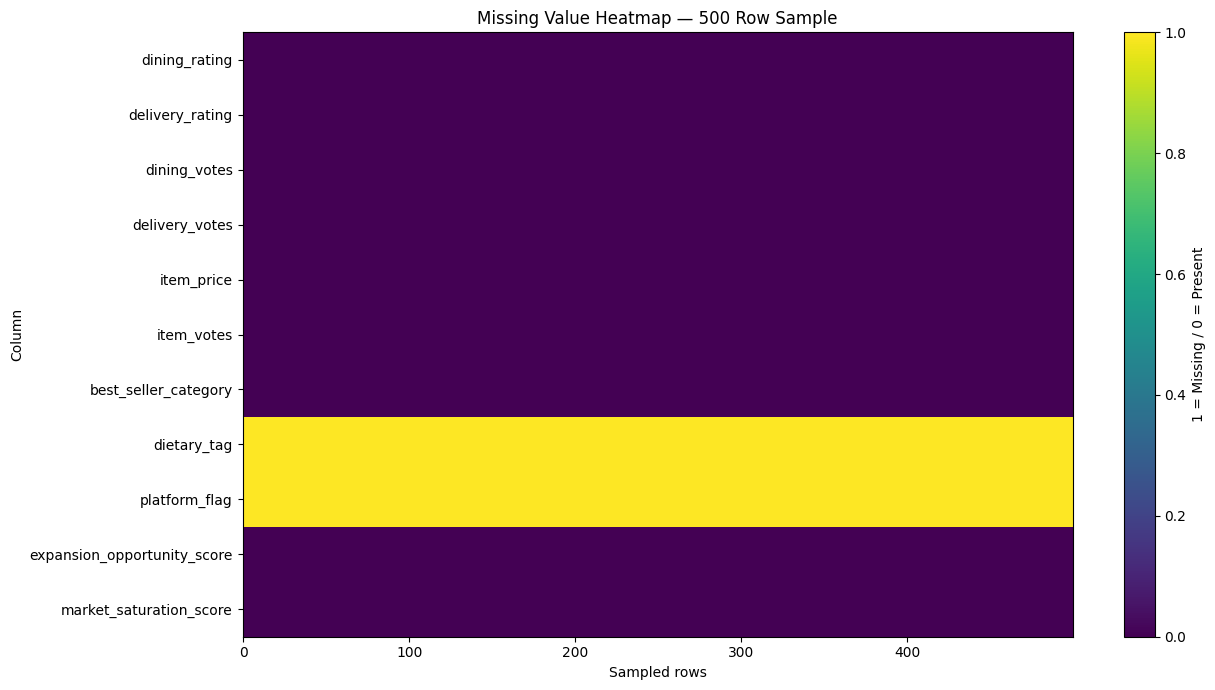

In [ ]:
fig, ax = plt.subplots(
    figsize=(13, 7)
)

image = ax.imshow(
    missing_matrix.T,
    aspect="auto",
    interpolation="nearest"
)

ax.set_yticks(
    np.arange(
        len(missing_matrix.columns)
    )
)

ax.set_yticklabels(
    missing_matrix.columns
)

ax.set_xlabel(
    "Sampled rows"
)

ax.set_ylabel(
    "Column"
)

ax.set_title(
    "Missing Value Heatmap — 500 Row Sample"
)

fig.colorbar(
    image,
    ax=ax,
    label="1 = Missing / 0 = Present"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "02_missing_value_heatmap.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 2. Duplicate Summary

In [ ]:
duplicate_query = f"""
SELECT

    COUNT(*) AS total_rows,

    COUNT(
        DISTINCT CONCAT_WS(
            '||',
            COALESCE(CAST(restaurant_key AS STRING), ''),
            COALESCE(restaurant_name, ''),
            COALESCE(city, ''),
            COALESCE(locality, ''),
            COALESCE(cuisine, ''),
            COALESCE(item_name, ''),
            COALESCE(CAST(item_price AS STRING), ''),
            COALESCE(CAST(item_votes AS STRING), '')
        )
    ) AS distinct_business_rows,

    COUNT(DISTINCT restaurant_key)
        AS distinct_restaurants,

    COUNT(DISTINCT item_name)
        AS distinct_menu_items

FROM {BRONZE}
"""

duplicate_summary = query_df(
    duplicate_query
)

duplicate_summary

,total_rows,distinct_business_rows,distinct_restaurants,distinct_menu_items
0,101530,97079,914,54719


In [ ]:
duplicate_summary.to_csv("duplicate_summary.csv",index=False)

### B - Univariate EDA

#### 3. Pull restaurant-level analytical data

In [41]:
restaurant_df = query_df(
    f"""
    SELECT
        restaurant_key,
        dining_rating,
        delivery_rating,
        dining_votes,
        delivery_votes,
        fulfillment_score,
        restaurant_density,
        same_cuisine_count,
        market_saturation_score,
        expansion_opportunity_score
    FROM {FACT_RESTAURANT}
    """
)

In [42]:
restaurant_numeric = [
    "dining_rating",
    "delivery_rating",
    "dining_votes",
    "delivery_votes",
    "fulfillment_score",
    "restaurant_density",
    "same_cuisine_count",
    "market_saturation_score",
    "expansion_opportunity_score"
]

for column in restaurant_numeric:

    restaurant_df[column] = pd.to_numeric(
        restaurant_df[column],
        errors="coerce"
    )

In [ ]:
restaurant_df.head()

,restaurant_key,dining_rating,delivery_rating,dining_votes,delivery_votes,fulfillment_score,restaurant_density,same_cuisine_count,market_saturation_score,expansion_opportunity_score
0,taco_bell__hyderabad__the_next_galleria_mall,4.3,3.7,117,0,3.94,2,1,0.0312,0.6129
1,ovenstory_pizza__hyderabad__abids,NaN,4.1,0,0,4.02,10,3,0.3812,0.4347
2,mcdonald's__hyderabad__mpm_mall,3.2,3.9,137,0,3.62,2,1,0.0312,0.4166
3,iqbal_cafe__hyderabad__charminar,3.1,4.3,12,0,3.82,17,1,0.5000,0.2594
4,mandi_town__hyderabad__khairatabad,3.4,3.8,5,535,3.64,2,1,0.0312,0.4680


In [ ]:
restaurant_df.to_csv("restaurant_df.csv",index=False)

#### 4. Pull menu-level analytical data

In [ ]:
menu_df = query_df(
    f"""
    SELECT
        restaurant_key,
        menu_item_key,
        item_price,
        item_votes,
        is_best_seller_marked
    FROM {FACT_MENU}
    """
)

In [ ]:
menu_df["item_price"] = pd.to_numeric(
    menu_df["item_price"],
    errors="coerce"
)

menu_df["item_votes"] = pd.to_numeric(
    menu_df["item_votes"],
    errors="coerce"
)

In [ ]:
menu_df.head()

,restaurant_key,menu_item_key,item_price,item_votes,is_best_seller_marked
0,doner_king__hyderabad__malakpet,40749,249.0,84,True
1,doner_king__hyderabad__malakpet,12095,129.0,45,True
2,doner_king__hyderabad__malakpet,12692,189.0,39,False
3,doner_king__hyderabad__malakpet,9129,189.0,43,True
4,doner_king__hyderabad__malakpet,46170,205.0,31,True


In [ ]:
menu_df.to_csv("menu_df.csv",index=False)

#### 5. Descriptive Statistics

In [ ]:
restaurant_stats = restaurant_df.describe().T
restaurant_stats

,count,mean,std,min,25%,50%,75%,max
dining_rating,619.0,3.792569,0.413889,2.5000,3.50000,3.8000,4.100000,4.8000
delivery_rating,891.0,3.957464,0.269369,2.5000,3.80000,4.0000,4.100000,4.6000
dining_votes,914.0,113.086433,199.508142,0.0000,0.00000,11.0000,134.500000,997.0000
delivery_votes,914.0,143.319475,263.823289,0.0000,0.00000,0.0000,172.750000,983.0000
fulfillment_score,914.0,3.900941,0.241010,3.0000,3.74000,3.9400,4.080000,4.6200
restaurant_density,914.0,5.326039,4.139257,1.0000,2.00000,4.0000,7.000000,17.0000
same_cuisine_count,914.0,1.922319,1.764778,1.0000,1.00000,1.0000,2.000000,11.0000
market_saturation_score,914.0,0.181301,0.187064,0.0000,0.03120,0.1250,0.281200,0.8500
expansion_opportunity_score,914.0,0.488868,0.087413,0.1528,0.44245,0.4996,0.547525,0.7579


In [ ]:
restaurant_stats.to_html("restaurant_stats.html")

In [ ]:
menu_stats = (
    menu_df[
        [
            "item_price",
            "item_votes"
        ]
    ]
    .describe()
    .T
)

menu_stats

,count,mean,std,min,25%,50%,75%,max
item_price,101529.0,243.692666,197.534499,0.95,130.0,209.0,299.0,12024.0
item_votes,101529.0,19.110510,108.264690,0.00,0.0,0.0,10.0,9750.0


In [ ]:
menu_stats.to_csv("menu_stats.csv",index=False)

#### 6. Histogram - Dining Rating

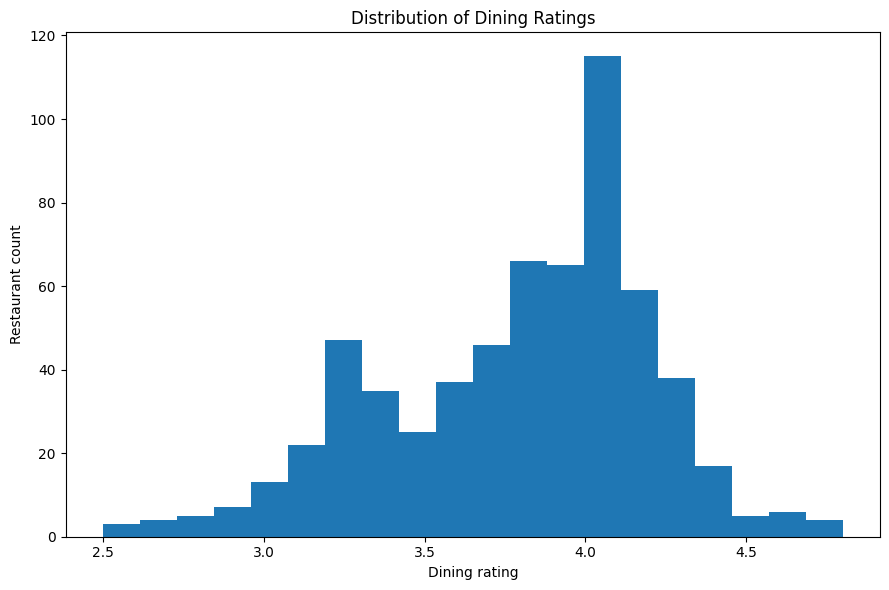

In [ ]:
values = (
    restaurant_df[
        "dining_rating"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    values,
    bins=20
)

ax.set_xlabel(
    "Dining rating"
)

ax.set_ylabel(
    "Restaurant count"
)

ax.set_title(
    "Distribution of Dining Ratings"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "03_hist_dining_rating.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 7. Histogram - Delivery Rating

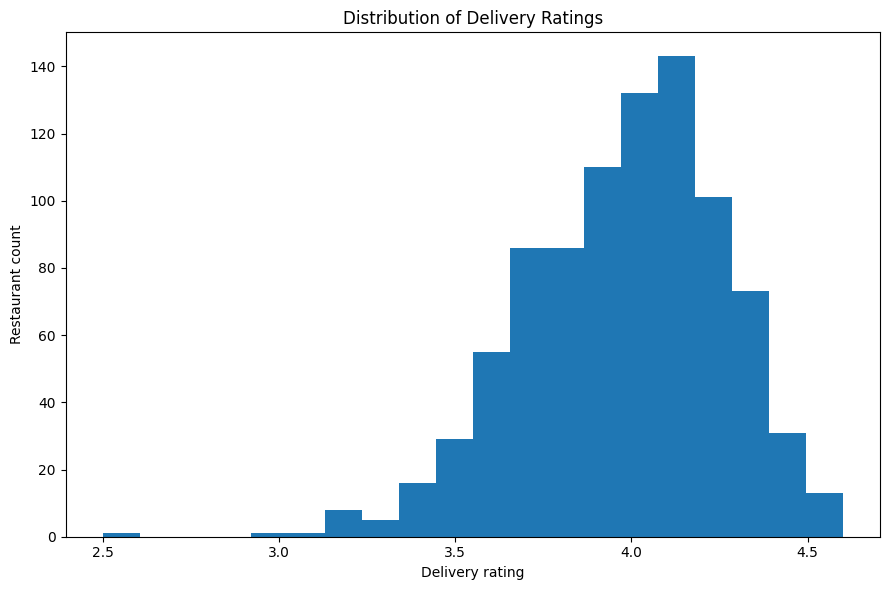

In [ ]:
values = (
    restaurant_df[
        "delivery_rating"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    values,
    bins=20
)

ax.set_xlabel(
    "Delivery rating"
)

ax.set_ylabel(
    "Restaurant count"
)

ax.set_title(
    "Distribution of Delivery Ratings"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "04_hist_delivery_rating.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 8. Histogram - Item Price

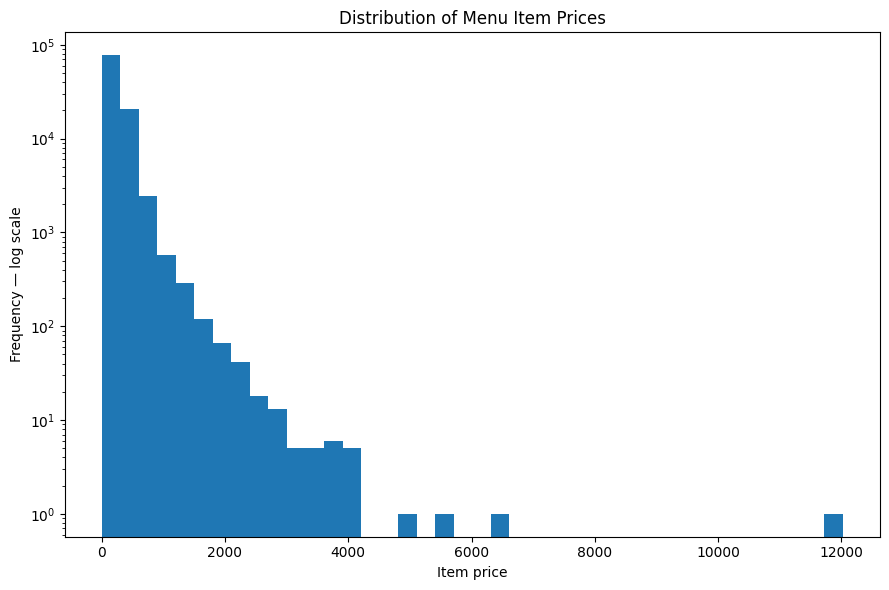

In [ ]:
values = (
    menu_df.loc[
        menu_df["item_price"] > 0,
        "item_price"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    values,
    bins=40,
    log=True
)

ax.set_xlabel(
    "Item price"
)

ax.set_ylabel(
    "Frequency — log scale"
)

ax.set_title(
    "Distribution of Menu Item Prices"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "05_hist_item_price.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 9. Histogram - Item Votes

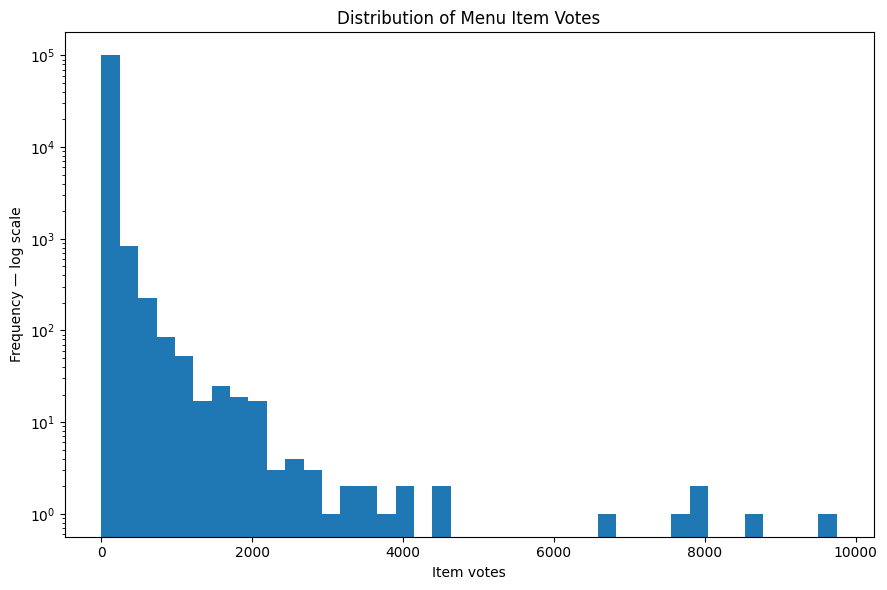

In [ ]:
values = (
    menu_df.loc[
        menu_df["item_votes"] >= 0,
        "item_votes"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.hist(
    values,
    bins=40,
    log=True
)

ax.set_xlabel(
    "Item votes"
)

ax.set_ylabel(
    "Frequency — log scale"
)

ax.set_title(
    "Distribution of Menu Item Votes"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "06_hist_item_votes.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 10. Boxplot - Item Price

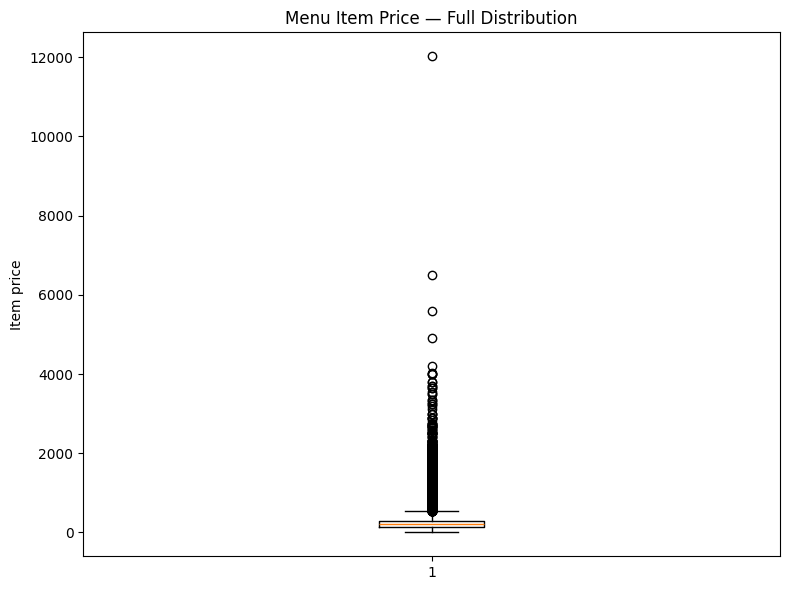

In [ ]:
values = (
    menu_df.loc[
        menu_df["item_price"] >= 0,
        "item_price"
    ]
    .dropna()
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.boxplot(
    values
)

ax.set_ylabel(
    "Item price"
)

ax.set_title(
    "Menu Item Price — Full Distribution"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "07_boxplot_item_price.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

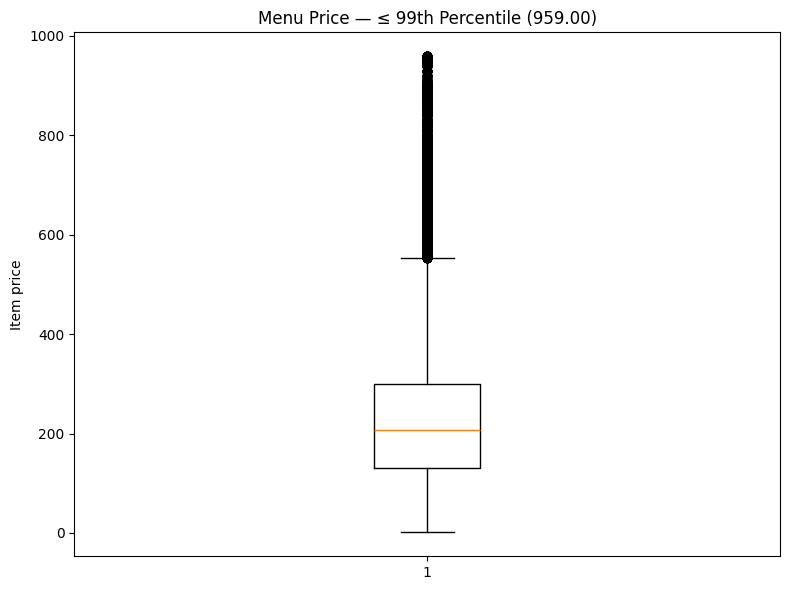

In [ ]:
p99 = values.quantile(0.99)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.boxplot(
    values[
        values <= p99
    ]
)

ax.set_ylabel(
    "Item price"
)

ax.set_title(
    f"Menu Price — ≤ 99th Percentile ({p99:.2f})"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "08_boxplot_item_price_p99.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### C - Categorical EDA

#### 11. Top 10 Cities

In [ ]:
top_cities = query_df(
    f"""
    SELECT
        c.city_name,
        COUNT(
            DISTINCT f.restaurant_key
        ) AS restaurant_count
    FROM {FACT_RESTAURANT} f
    JOIN {DIM_CITY} c
        ON f.city_key = c.city_key
    GROUP BY c.city_name
    ORDER BY restaurant_count DESC
    LIMIT 10
    """
)

top_cities

,city_name,restaurant_count
0,Hyderabad,130
1,Jaipur,92
2,Chennai,87
3,Bangalore,83
4,Mumbai,80
5,Ahmedabad,74
6,Kochi,73
7,Kolkata,64
8,Pune,60
9,Lucknow,58


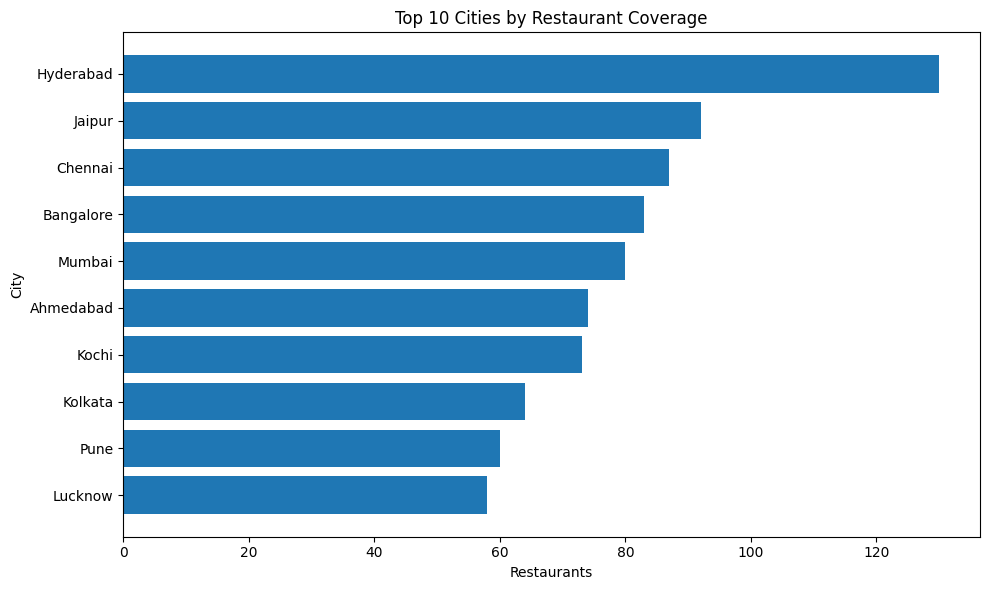

In [ ]:
plot_df = (
    top_cities
    .sort_values(
        "restaurant_count",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_df["city_name"],
    plot_df["restaurant_count"]
)

ax.set_xlabel(
    "Restaurants"
)

ax.set_ylabel(
    "City"
)

ax.set_title(
    "Top 10 Cities by Restaurant Coverage"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "09_top_10_cities.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 12. Top 10 Localities

In [ ]:
top_localities = query_df(
    f"""
    SELECT
        c.city_name,
        l.locality_name,
        COUNT(
            DISTINCT f.restaurant_key
        ) AS restaurant_count
    FROM {FACT_RESTAURANT} f
    JOIN {DIM_CITY} c
        ON f.city_key = c.city_key
    JOIN {DIM_LOCALITY} l
        ON f.locality_key = l.locality_key
    GROUP BY
        c.city_name,
        l.locality_name
    ORDER BY restaurant_count DESC
    LIMIT 10
    """
)

top_localities["label"] = (
    top_localities["city_name"]
    + " — "
    + top_localities["locality_name"]
)

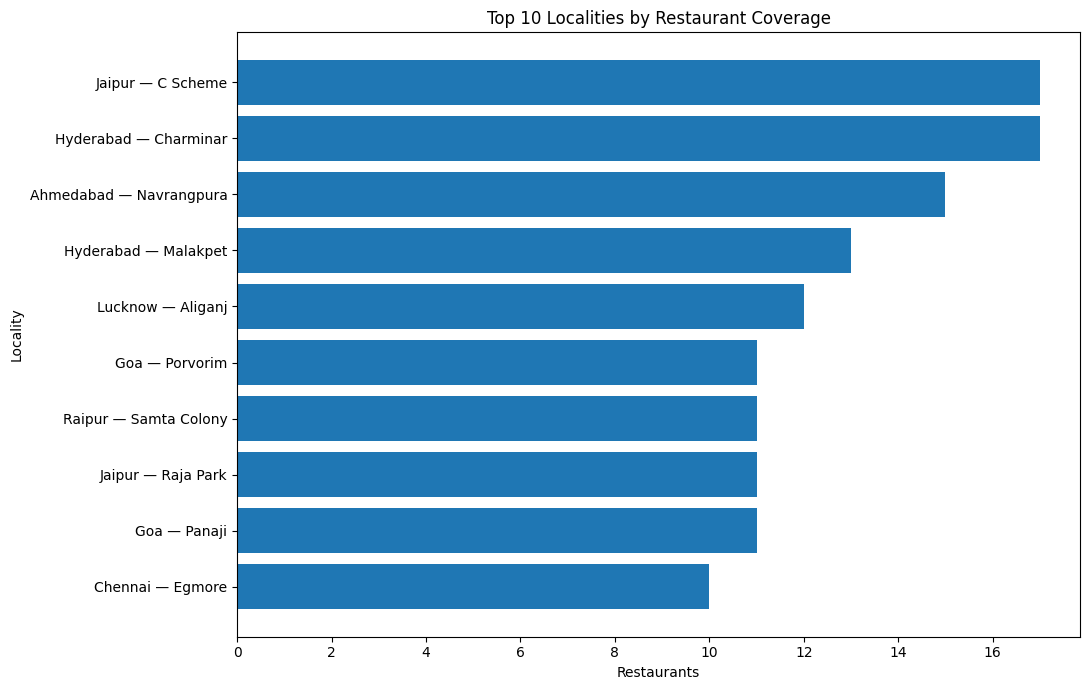

In [ ]:
plot_df = (
    top_localities
    .sort_values(
        "restaurant_count",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_df["label"],
    plot_df["restaurant_count"]
)

ax.set_xlabel(
    "Restaurants"
)

ax.set_ylabel(
    "Locality"
)

ax.set_title(
    "Top 10 Localities by Restaurant Coverage"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "10_top_10_localities.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 13. Top 10 Cuisines

In [ ]:
top_cuisines = query_df(
    f"""
    SELECT
        c.cuisine_name,
        COUNT(
            DISTINCT b.restaurant_key
        ) AS restaurant_count
    FROM {BRIDGE_CUISINE} b
    JOIN {DIM_CUISINE} c
        ON b.cuisine_key = c.cuisine_key
    GROUP BY c.cuisine_name
    ORDER BY restaurant_count DESC
    LIMIT 10
    """
)

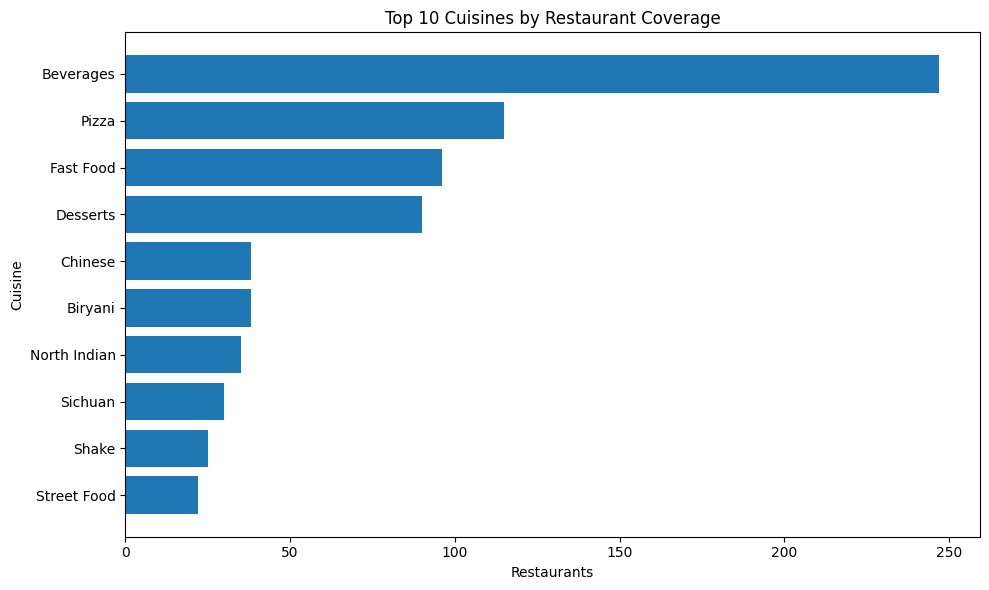

In [ ]:
plot_df = top_cuisines.sort_values(
    "restaurant_count",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    plot_df["cuisine_name"],
    plot_df["restaurant_count"]
)

ax.set_xlabel(
    "Restaurants"
)

ax.set_ylabel(
    "Cuisine"
)

ax.set_title(
    "Top 10 Cuisines by Restaurant Coverage"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "11_top_10_cuisines.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 14. Best-Seller Category Distribution

In [ ]:
best_seller = query_df(
    f"""
    SELECT
        COALESCE(
            best_seller_category,
            'NOT MARKED'
        ) AS best_seller_category,

        COUNT(*) AS item_count

    FROM {BRONZE}

    GROUP BY
        COALESCE(
            best_seller_category,
            'NOT MARKED'
        )

    ORDER BY item_count DESC
    """
)

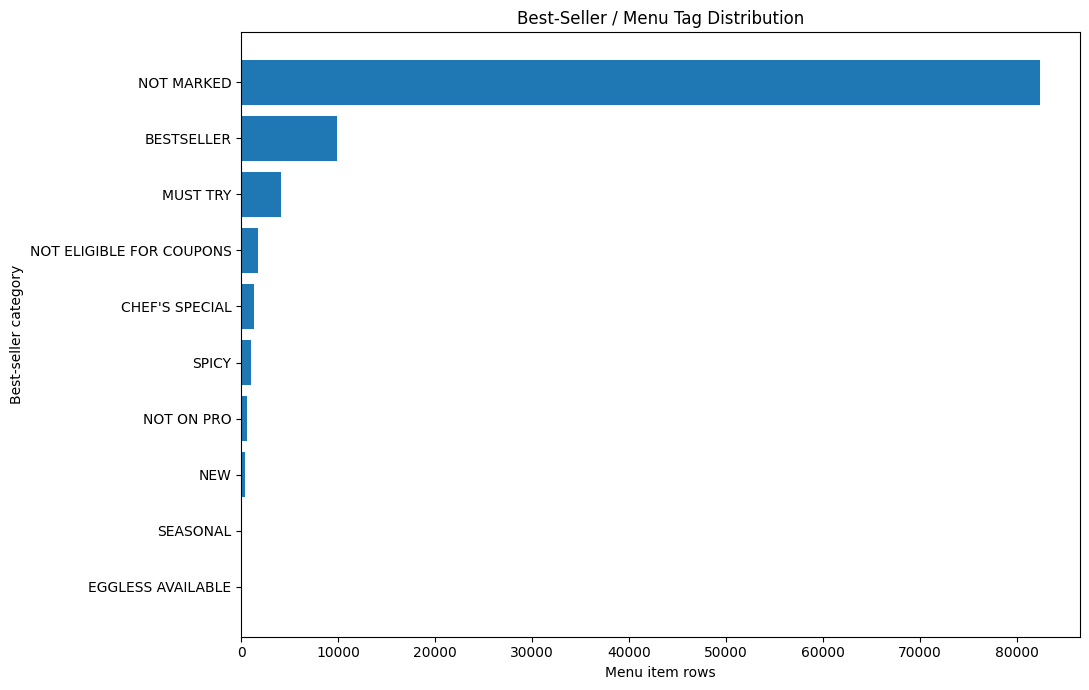

In [ ]:
plot_df = best_seller.sort_values(
    "item_count",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    plot_df["best_seller_category"],
    plot_df["item_count"]
)

ax.set_xlabel(
    "Menu item rows"
)

ax.set_ylabel(
    "Best-seller category"
)

ax.set_title(
    "Best-Seller / Menu Tag Distribution"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "12_best_seller_category_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 15. Price-Band Distribution

In [ ]:
price_band = query_df(
    f"""
    SELECT
        p.price_band,
        COUNT(*) AS menu_item_count
    FROM {FACT_MENU} f
    JOIN {DIM_PRICE} p
        ON f.price_band_key = p.price_band_key
    GROUP BY
        p.price_band_key,
        p.price_band
    ORDER BY
        p.price_band_key
    """
)

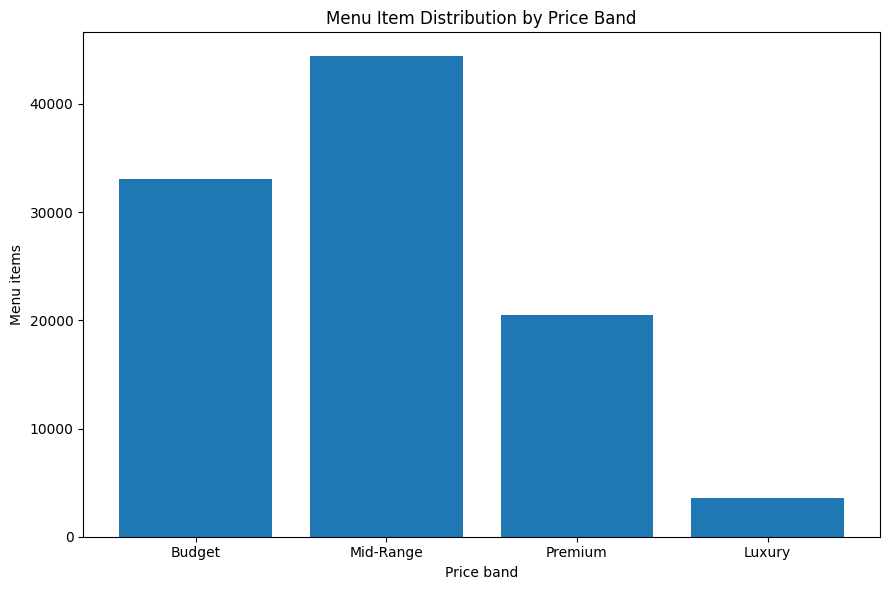

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.bar(
    price_band["price_band"],
    price_band["menu_item_count"]
)

ax.set_xlabel(
    "Price band"
)

ax.set_ylabel(
    "Menu items"
)

ax.set_title(
    "Menu Item Distribution by Price Band"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "13_price_band_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 16. Rating-Band Distribution

In [ ]:
rating_band_df = restaurant_df.copy()

rating_band_df["rating_band"] = pd.cut(
    rating_band_df["dining_rating"],
    bins=[
        -np.inf,
        3.0,
        4.0,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

rating_counts = (
    rating_band_df["rating_band"]
    .value_counts()
    .reindex(
        [
            "Low",
            "Medium",
            "High"
        ]
    )
    .fillna(0)
)

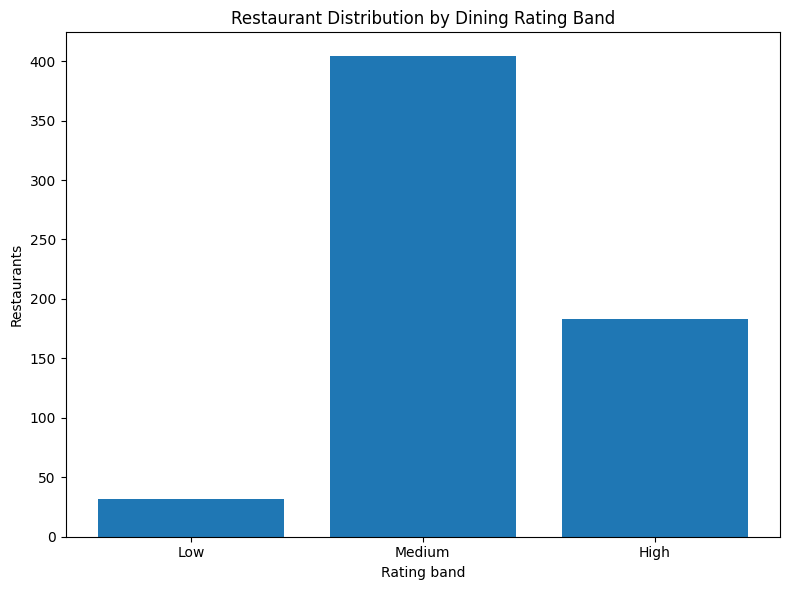

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

ax.set_xlabel(
    "Rating band"
)

ax.set_ylabel(
    "Restaurants"
)

ax.set_title(
    "Restaurant Distribution by Dining Rating Band"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "14_rating_band_distribution.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### D - Relationship Analysis

#### 17. Rating vs Votes

In [ ]:
rating_votes = query_df(
    f"""
    SELECT
        dining_rating,
        dining_votes

    FROM {FACT_RESTAURANT}

    WHERE dining_rating IS NOT NULL
      AND dining_votes IS NOT NULL
      AND dining_votes >= 0
    """
)

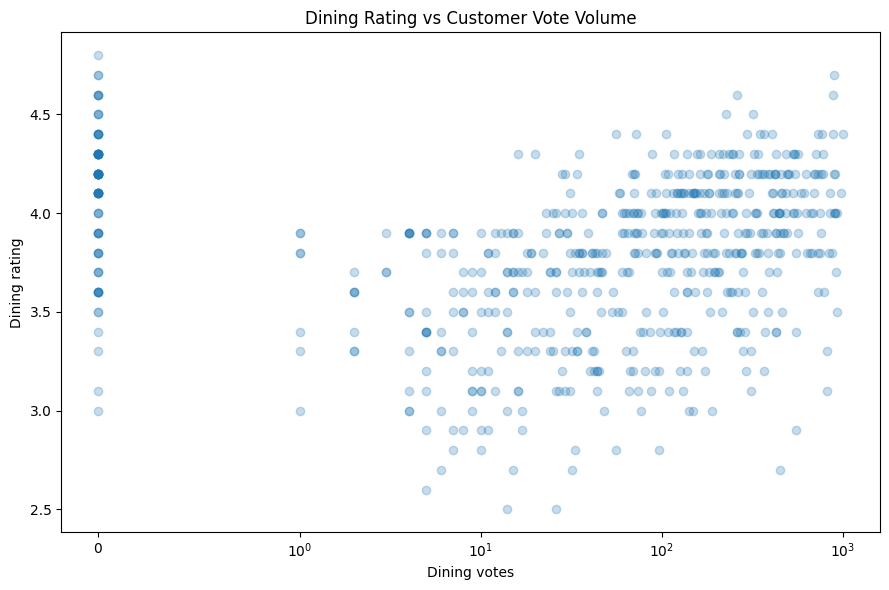

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    rating_votes["dining_votes"],
    rating_votes["dining_rating"],
    alpha=0.25
)

ax.set_xscale(
    "symlog",
    linthresh=1
)

ax.set_xlabel(
    "Dining votes"
)

ax.set_ylabel(
    "Dining rating"
)

ax.set_title(
    "Dining Rating vs Customer Vote Volume"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "15_rating_vs_votes.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 18. Price vs Votes

In [ ]:
price_votes = menu_df.dropna(
    subset=[
        "item_price",
        "item_votes"
    ]
)

price_votes = price_votes[
    (price_votes["item_price"] >= 0)
    &
    (price_votes["item_votes"] >= 0)
]

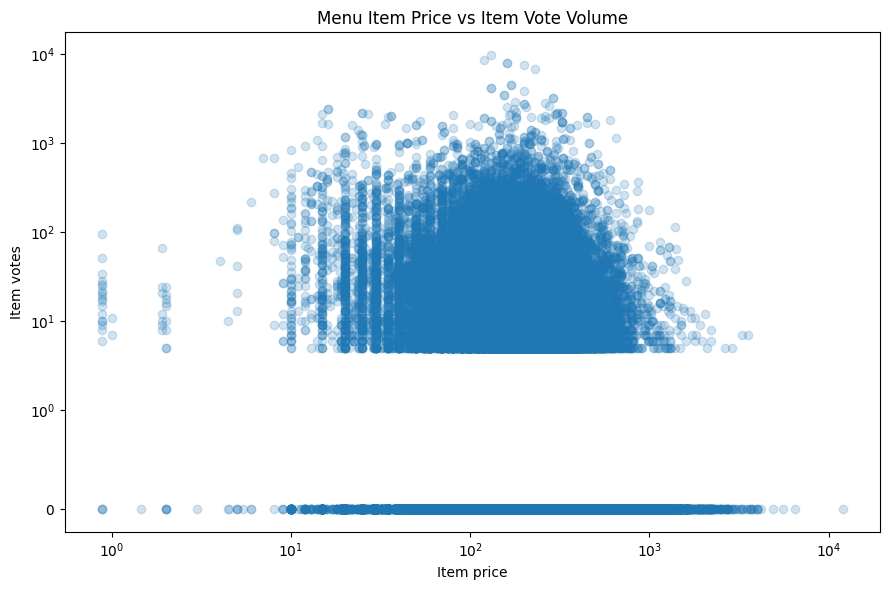

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    price_votes["item_price"],
    price_votes["item_votes"],
    alpha=0.20
)

ax.set_xscale(
    "symlog",
    linthresh=1
)

ax.set_yscale(
    "symlog",
    linthresh=1
)

ax.set_xlabel(
    "Item price"
)

ax.set_ylabel(
    "Item votes"
)

ax.set_title(
    "Menu Item Price vs Item Vote Volume"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "16_price_vs_votes.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 19. Rating vs Expansion Score

In [ ]:
rating_expansion = query_df(
    f"""
    SELECT
        dining_rating,
        expansion_opportunity_score
    FROM {FACT_RESTAURANT}
    WHERE dining_rating IS NOT NULL
      AND expansion_opportunity_score IS NOT NULL
    """
)

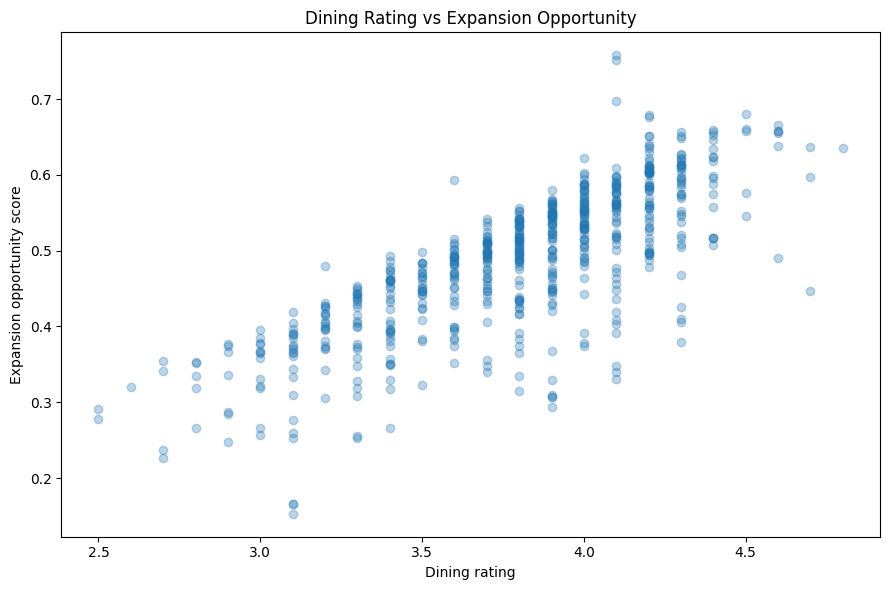

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    rating_expansion["dining_rating"],
    rating_expansion[
        "expansion_opportunity_score"
    ],
    alpha=0.30
)

ax.set_xlabel(
    "Dining rating"
)

ax.set_ylabel(
    "Expansion opportunity score"
)

ax.set_title(
    "Dining Rating vs Expansion Opportunity"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "17_rating_vs_expansion_score.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 20. Rating vs Expansion Score

In [ ]:
rating_expansion = query_df(
    f"""
    SELECT
        dining_rating,
        expansion_opportunity_score
    FROM {FACT_RESTAURANT}
    WHERE dining_rating IS NOT NULL
      AND expansion_opportunity_score IS NOT NULL
    """
)

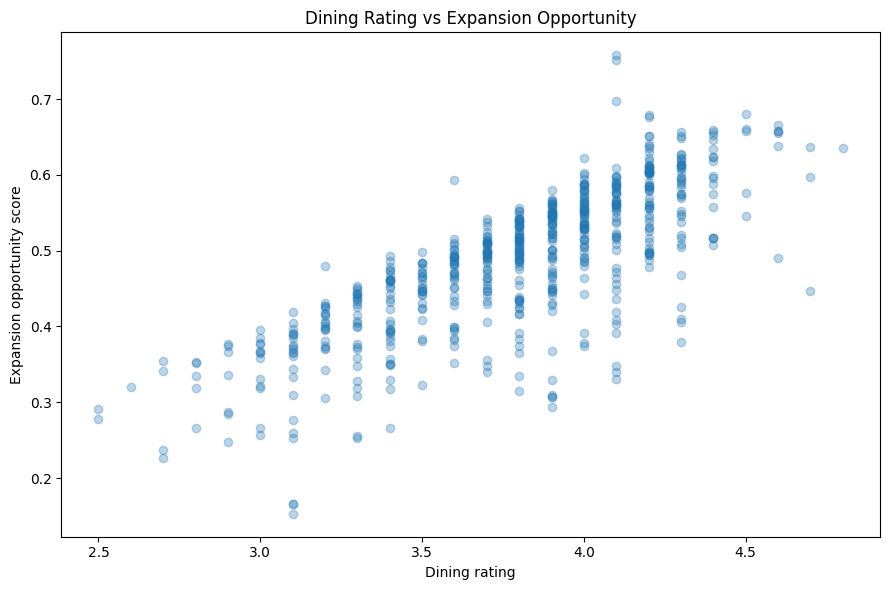

In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    rating_expansion["dining_rating"],
    rating_expansion[
        "expansion_opportunity_score"
    ],
    alpha=0.30
)

ax.set_xlabel(
    "Dining rating"
)

ax.set_ylabel(
    "Expansion opportunity score"
)

ax.set_title(
    "Dining Rating vs Expansion Opportunity"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "17_rating_vs_expansion_score.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 21. Saturation vs Expansion Score

In [10]:
sat_exp = query_df(
    f"""
    SELECT
        market_saturation_score,
        expansion_opportunity_score
    FROM {FACT_RESTAURANT}
    WHERE market_saturation_score IS NOT NULL
      AND expansion_opportunity_score IS NOT NULL
    """
)

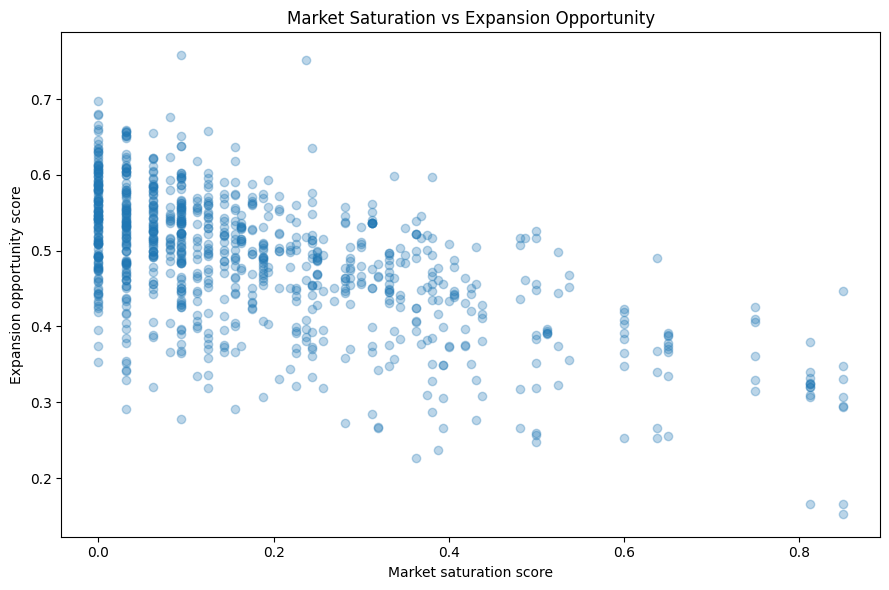

In [11]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    sat_exp[
        "market_saturation_score"
    ],
    sat_exp[
        "expansion_opportunity_score"
    ],
    alpha=0.30
)

ax.set_xlabel(
    "Market saturation score"
)

ax.set_ylabel(
    "Expansion opportunity score"
)

ax.set_title(
    "Market Saturation vs Expansion Opportunity"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "18_saturation_vs_expansion_score.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 22. City-Wise Boxplot of Ratings

In [12]:
city_ratings = query_df(
    f"""
    SELECT
        c.city_name,
        f.dining_rating

    FROM {FACT_RESTAURANT} f

    JOIN {DIM_CITY} c
        ON f.city_key = c.city_key

    WHERE f.dining_rating IS NOT NULL
    """
)

In [13]:
top_city_order = (
    city_ratings
    .groupby("city_name")[
        "dining_rating"
    ]
    .count()
    .sort_values(
        ascending=False
    )
    .head(12)
    .index
)

In [14]:
box_data = [
    city_ratings.loc[
        city_ratings["city_name"] == city,
        "dining_rating"
    ]
    for city in top_city_order
]

C:\Users\harsh\AppData\Local\Temp\ipykernel_4624\1765534434.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


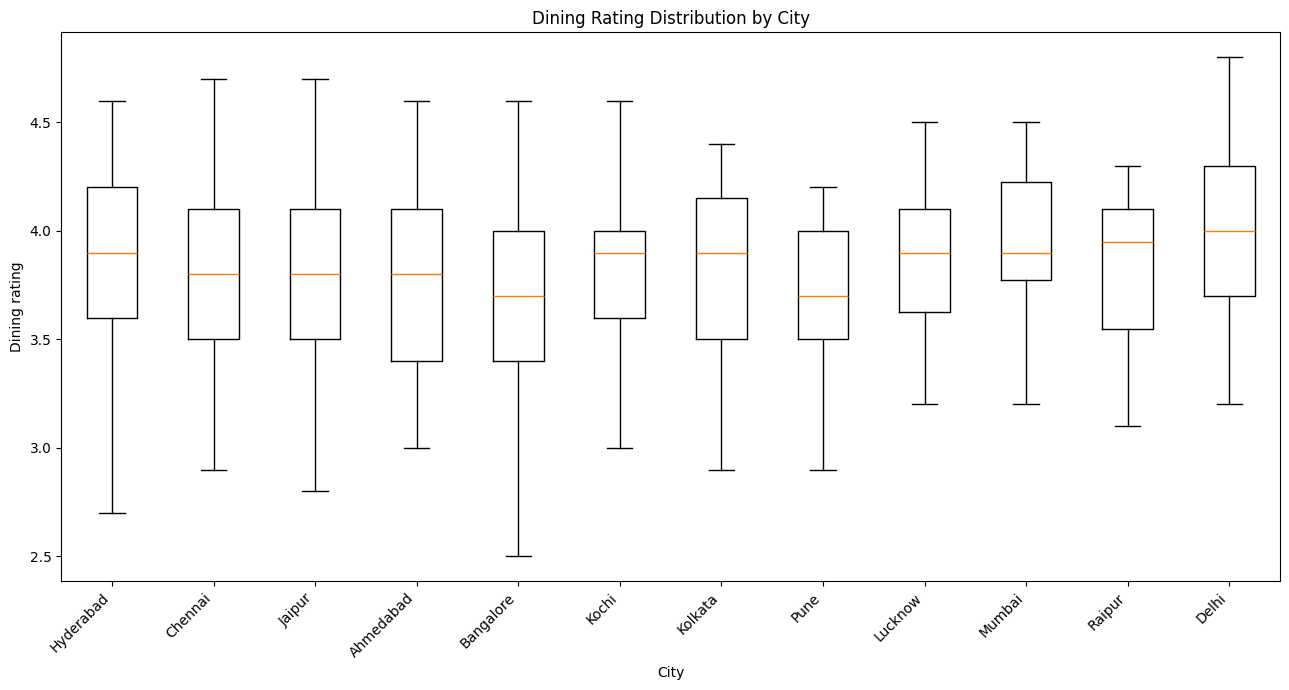

In [15]:
fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.boxplot(
    box_data,
    labels=top_city_order,
    showfliers=False
)

ax.set_xlabel(
    "City"
)

ax.set_ylabel(
    "Dining rating"
)

ax.set_title(
    "Dining Rating Distribution by City"
)

plt.xticks(
    rotation=45,
    ha="right"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "19_citywise_rating_boxplot.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 23. Cuisine-wise price boxplot

In [16]:
cuisine_prices = query_df(
    f"""
    SELECT
        c.cuisine_name,
        f.item_price

    FROM {FACT_MENU} f

    JOIN {DIM_CUISINE} c
        ON f.cuisine_key = c.cuisine_key

    WHERE f.item_price IS NOT NULL
      AND f.item_price >= 0
    """
)

In [17]:
top_cuisine_order = (
    cuisine_prices
    .groupby("cuisine_name")[
        "item_price"
    ]
    .count()
    .sort_values(
        ascending=False
    )
    .head(12)
    .index
)

In [18]:
box_data = [
    cuisine_prices.loc[
        cuisine_prices["cuisine_name"] == cuisine,
        "item_price"
    ]
    for cuisine in top_cuisine_order
]

C:\Users\harsh\AppData\Local\Temp\ipykernel_4624\1995663792.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


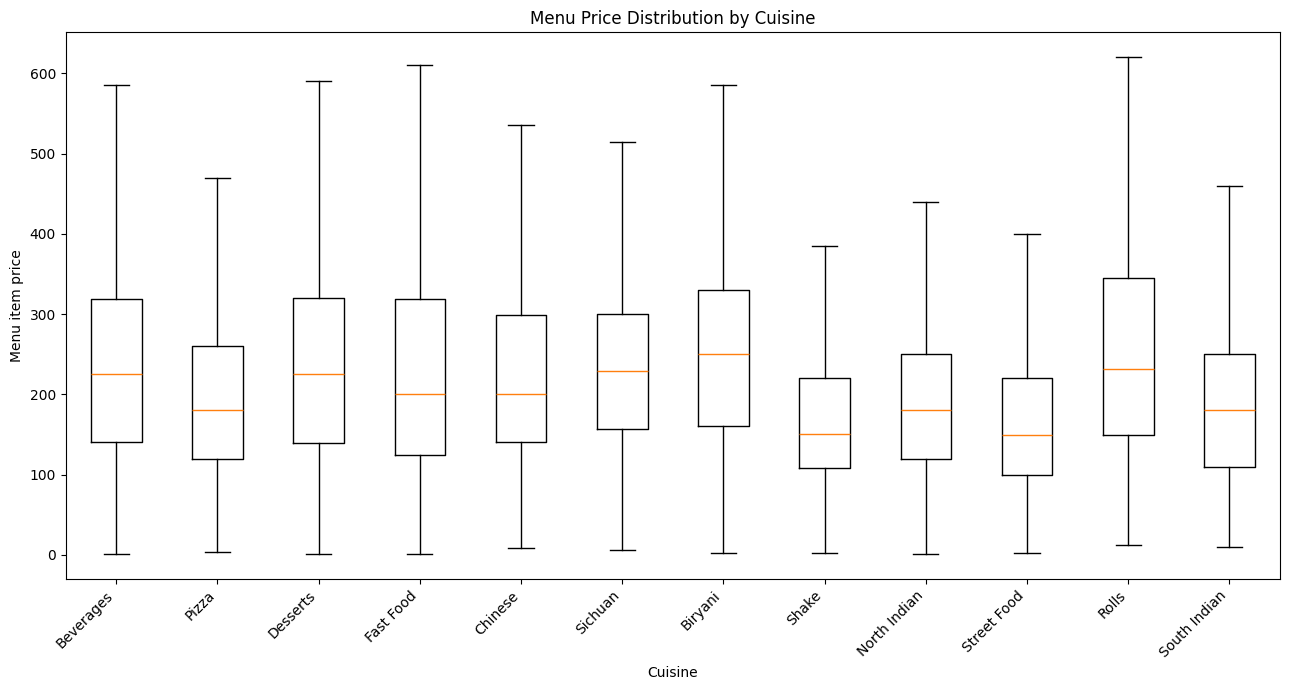

In [19]:
fig, ax = plt.subplots(
    figsize=(13, 7)
)

ax.boxplot(
    box_data,
    labels=top_cuisine_order,
    showfliers=False
)

ax.set_xlabel(
    "Cuisine"
)

ax.set_ylabel(
    "Menu item price"
)

ax.set_title(
    "Menu Price Distribution by Cuisine"
)

plt.xticks(
    rotation=45,
    ha="right"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "20_cuisinewise_price_boxplot.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

### E - Market Intelligence

#### 24. City Performance Ranking

In [20]:
city_performance = query_df(
    f"""
    SELECT
        city_name,
        restaurant_count,
        avg_dining_rating,
        avg_delivery_rating,
        avg_saturation_score,
        avg_expansion_score

    FROM {GOLD_CITY}

    ORDER BY avg_expansion_score DESC
    """
)

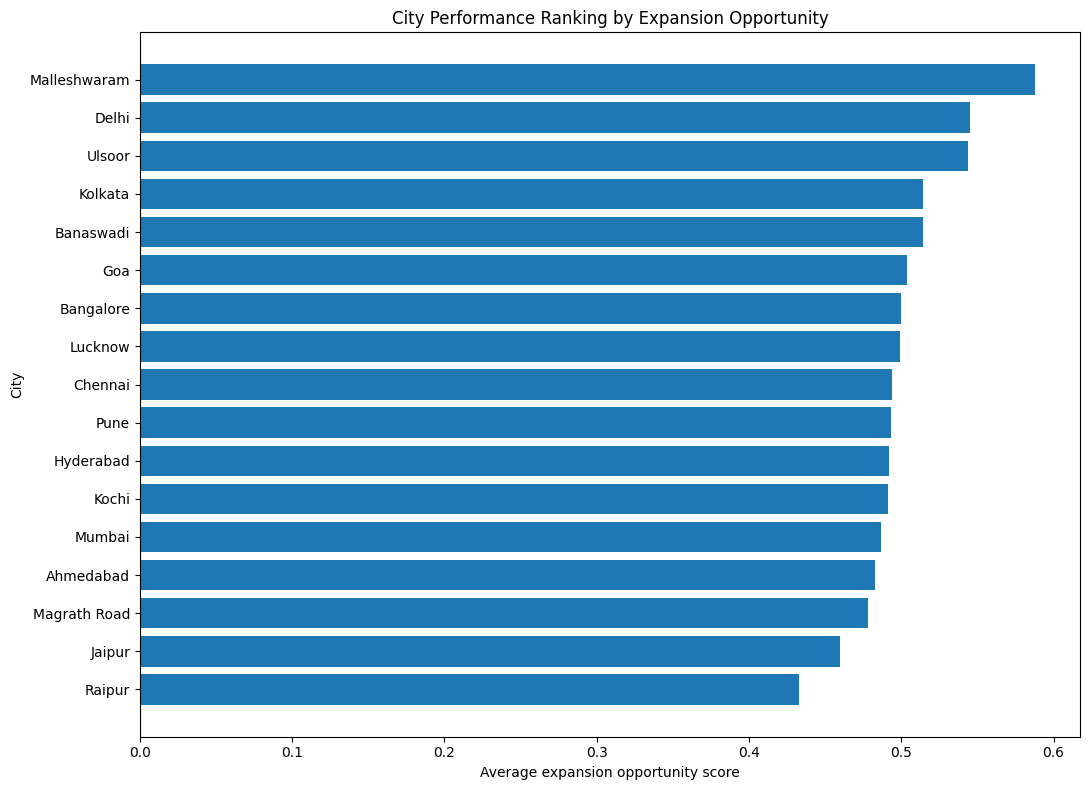

In [21]:
plot_df = city_performance.sort_values(
    "avg_expansion_score",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

ax.barh(
    plot_df["city_name"],
    plot_df["avg_expansion_score"]
)

ax.set_xlabel(
    "Average expansion opportunity score"
)

ax.set_ylabel(
    "City"
)

ax.set_title(
    "City Performance Ranking by Expansion Opportunity"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "21_city_performance_ranking.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 25. Locality Opportunity Ranking

In [23]:
locality_performance = query_df(
    f"""
    SELECT
        city_name,
        locality_name,
        restaurant_count,
        avg_dining_rating,
        avg_delivery_rating,
        avg_saturation_score,
        avg_expansion_score

    FROM {GOLD_LOCALITY}

    ORDER BY avg_expansion_score DESC

    LIMIT 20
    """
)

In [24]:
locality_performance["label"] = (
    locality_performance["city_name"]
    + " — "
    + locality_performance["locality_name"]
)

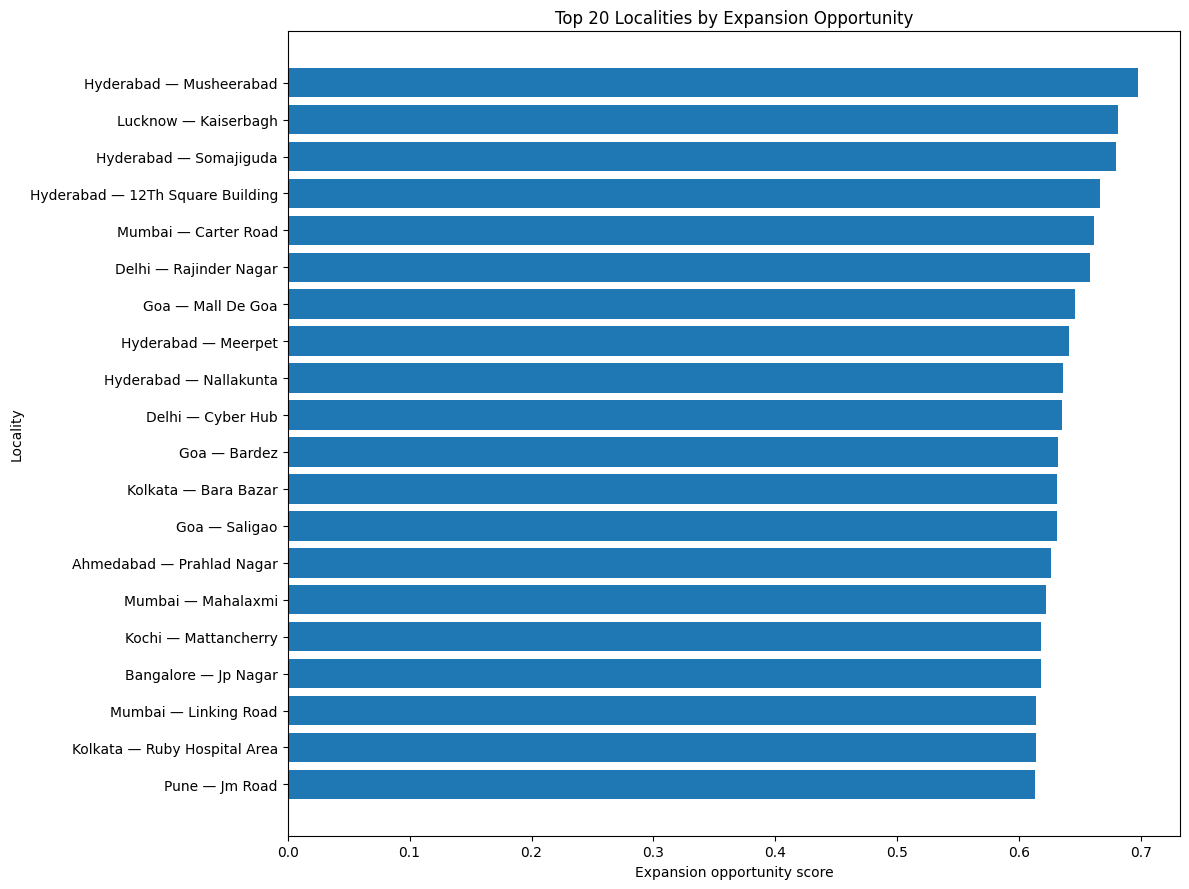

In [25]:
plot_df = locality_performance.sort_values(
    "avg_expansion_score",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(12, 9)
)

ax.barh(
    plot_df["label"],
    plot_df["avg_expansion_score"]
)

ax.set_xlabel(
    "Expansion opportunity score"
)

ax.set_ylabel(
    "Locality"
)

ax.set_title(
    "Top 20 Localities by Expansion Opportunity"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "22_locality_opportunity_ranking.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 26. Cuisine Concentration By City

In [26]:
cuisine_city = query_df(
    f"""
    SELECT
        city.city_name,
        cuisine.cuisine_name,
        COUNT(
            DISTINCT b.restaurant_key
        ) AS restaurant_count

    FROM {BRIDGE_CUISINE} b

    JOIN {DIM_CUISINE} cuisine
        ON b.cuisine_key = cuisine.cuisine_key

    JOIN {FACT_RESTAURANT} f
        ON b.restaurant_key = f.restaurant_key

    JOIN {DIM_CITY} city
        ON f.city_key = city.city_key

    GROUP BY
        city.city_name,
        cuisine.cuisine_name
    """
)

In [27]:
city_totals = (
    cuisine_city
    .groupby("city_name")[
        "restaurant_count"
    ]
    .sum()
)

cuisine_city["city_total"] = (
    cuisine_city["city_name"]
    .map(city_totals)
)

cuisine_city["share_pct"] = (
    cuisine_city["restaurant_count"]
    /
    cuisine_city["city_total"]
    *
    100
)

In [28]:
top_global_cuisines = (
    cuisine_city
    .groupby("cuisine_name")[
        "restaurant_count"
    ]
    .sum()
    .nlargest(8)
    .index
)

In [29]:
cuisine_pivot = (
    cuisine_city[
        cuisine_city[
            "cuisine_name"
        ].isin(top_global_cuisines)
    ]
    .pivot_table(
        index="city_name",
        columns="cuisine_name",
        values="share_pct",
        aggfunc="sum",
        fill_value=0
    )
)

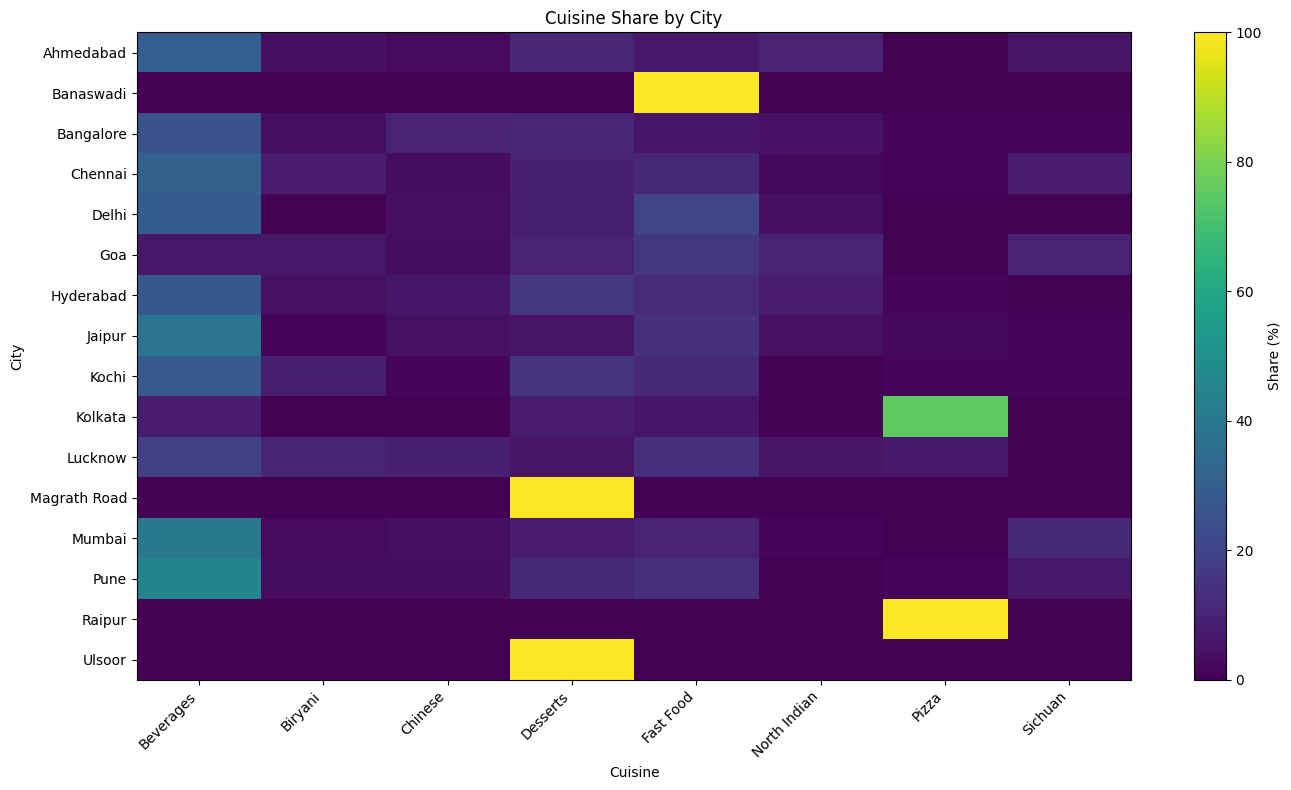

In [30]:
fig, ax = plt.subplots(
    figsize=(14, 8)
)

image = ax.imshow(
    cuisine_pivot.values,
    aspect="auto",
    interpolation="nearest"
)

ax.set_yticks(
    np.arange(
        len(cuisine_pivot.index)
    )
)

ax.set_yticklabels(
    cuisine_pivot.index
)

ax.set_xticks(
    np.arange(
        len(cuisine_pivot.columns)
    )
)

ax.set_xticklabels(
    cuisine_pivot.columns,
    rotation=45,
    ha="right"
)

ax.set_xlabel(
    "Cuisine"
)

ax.set_ylabel(
    "City"
)

ax.set_title(
    "Cuisine Share by City"
)

fig.colorbar(
    image,
    ax=ax,
    label="Share (%)"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "23_cuisine_concentration_by_city.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 27. Price-Band Share By City

In [31]:
city_price = query_df(
    f"""
    SELECT
        c.city_name,
        p.price_band,
        COUNT(*) AS menu_item_count

    FROM {FACT_MENU} f

    JOIN {DIM_PRICE} p
        ON f.price_band_key = p.price_band_key

    JOIN {FACT_RESTAURANT} r
        ON f.restaurant_key = r.restaurant_key

    JOIN {DIM_CITY} c
        ON r.city_key = c.city_key

    GROUP BY
        c.city_name,
        p.price_band
    """
)

In [32]:
city_price["city_total"] = (
    city_price
    .groupby("city_name")[
        "menu_item_count"
    ]
    .transform("sum")
)

city_price["share_pct"] = (
    city_price["menu_item_count"]
    /
    city_price["city_total"]
    *
    100
)

In [33]:
price_order = [
    "Budget",
    "Mid-Range",
    "Premium",
    "Luxury"
]

price_pivot = (
    city_price
    .pivot_table(
        index="city_name",
        columns="price_band",
        values="share_pct",
        aggfunc="sum",
        fill_value=0
    )
)

available_order = [
    x for x in price_order
    if x in price_pivot.columns
]

price_pivot = price_pivot[
    available_order
]

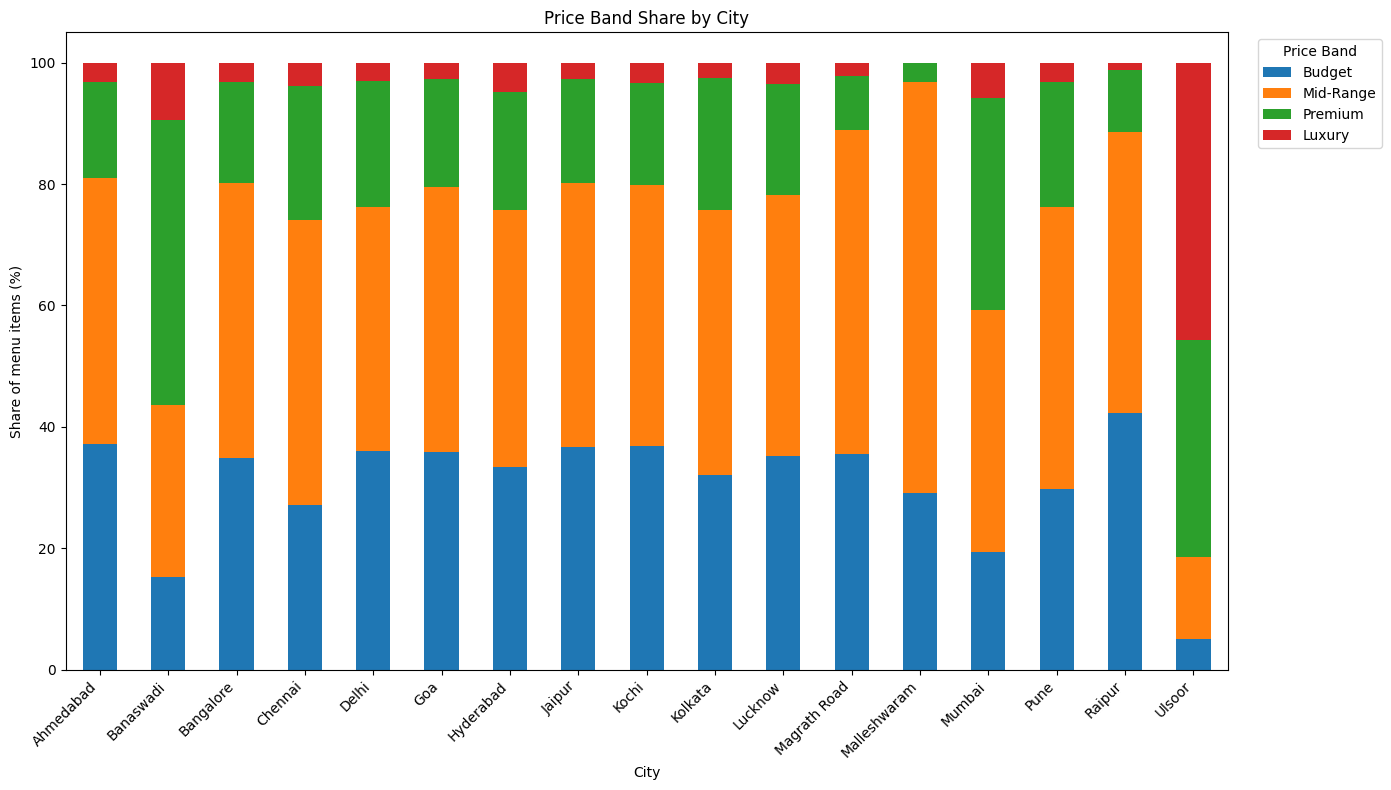

In [34]:
fig, ax = plt.subplots(
    figsize=(14, 8)
)

price_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel(
    "City"
)

ax.set_ylabel(
    "Share of menu items (%)"
)

ax.set_title(
    "Price Band Share by City"
)

ax.legend(
    title="Price Band",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=45,
    ha="right"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "24_price_band_share_by_city.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 28. Saturation Heatmap

In [35]:
saturation = query_df(
    f"""
    SELECT
        c.city_name,
        l.locality_name,
        AVG(
            f.market_saturation_score
        ) AS saturation_score,

        COUNT(
            DISTINCT f.restaurant_key
        ) AS restaurant_count

    FROM {FACT_RESTAURANT} f

    JOIN {DIM_CITY} c
        ON f.city_key = c.city_key

    JOIN {DIM_LOCALITY} l
        ON f.locality_key = l.locality_key

    GROUP BY
        c.city_name,
        l.locality_name
    """
)

In [36]:
top_localities = (
    saturation
    .groupby("locality_name")[
        "restaurant_count"
    ]
    .sum()
    .nlargest(15)
    .index
)

In [37]:
heat_source = saturation[
    saturation["locality_name"].isin(
        top_localities
    )
]

In [38]:
saturation_pivot = (
    heat_source
    .pivot_table(
        index="city_name",
        columns="locality_name",
        values="saturation_score",
        aggfunc="mean"
    )
)

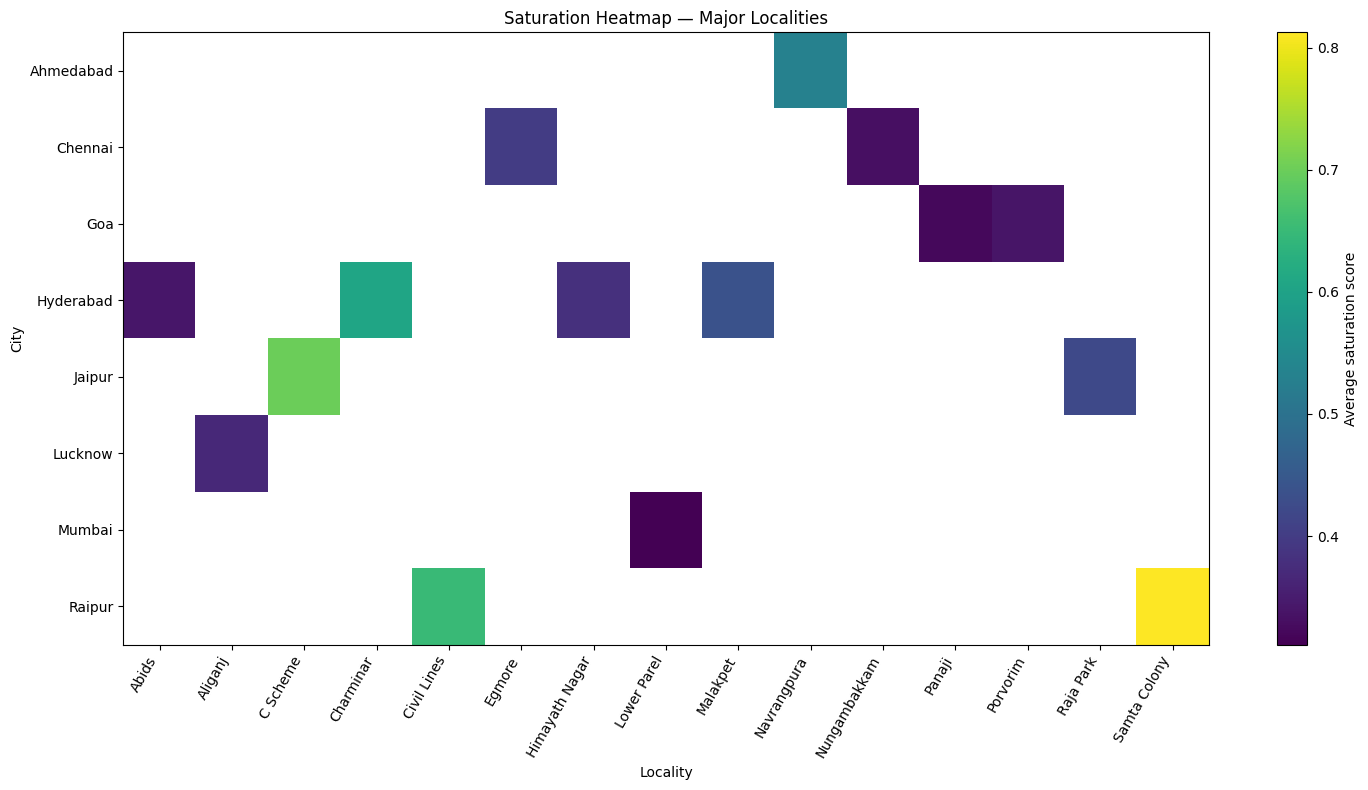

In [39]:
fig, ax = plt.subplots(
    figsize=(15, 8)
)

image = ax.imshow(
    saturation_pivot.values,
    aspect="auto",
    interpolation="nearest"
)

ax.set_yticks(
    np.arange(
        len(saturation_pivot.index)
    )
)

ax.set_yticklabels(
    saturation_pivot.index
)

ax.set_xticks(
    np.arange(
        len(saturation_pivot.columns)
    )
)

ax.set_xticklabels(
    saturation_pivot.columns,
    rotation=60,
    ha="right"
)

ax.set_xlabel(
    "Locality"
)

ax.set_ylabel(
    "City"
)

ax.set_title(
    "Saturation Heatmap — Major Localities"
)

fig.colorbar(
    image,
    ax=ax,
    label="Average saturation score"
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "25_saturation_heatmap.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 29. Correlatin Analysis

In [43]:
corr_columns = [
    "dining_rating",
    "delivery_rating",
    "dining_votes",
    "delivery_votes",
    "fulfillment_score",
    "restaurant_density",
    "same_cuisine_count",
    "market_saturation_score",
    "expansion_opportunity_score"
]

corr = (
    restaurant_df[
        corr_columns
    ]
    .corr(
        method="spearman"
    )
)

corr

,dining_rating,delivery_rating,dining_votes,delivery_votes,fulfillment_score,restaurant_density,same_cuisine_count,market_saturation_score,expansion_opportunity_score
dining_rating,1.000000,0.268686,0.173325,-0.200902,0.811024,-0.006743,0.004123,-0.007211,0.778052
delivery_rating,0.268686,1.000000,-0.007178,-0.083748,0.779061,-0.002618,0.053785,0.009819,0.138948
dining_votes,0.173325,-0.007178,1.000000,-0.308461,-0.007987,-0.017584,0.057938,0.001338,0.047783
delivery_votes,-0.200902,-0.083748,-0.308461,1.000000,-0.139088,0.027433,-0.018704,0.015349,-0.064054
fulfillment_score,0.811024,0.779061,-0.007987,-0.139088,1.000000,0.021177,0.052783,0.030083,0.545728
restaurant_density,-0.006743,-0.002618,-0.017584,0.027433,0.021177,1.000000,0.491543,0.961162,-0.510329
same_cuisine_count,0.004123,0.053785,0.057938,-0.018704,0.052783,0.491543,1.000000,0.690103,-0.412890
market_saturation_score,-0.007211,0.009819,0.001338,0.015349,0.030083,0.961162,0.690103,1.000000,-0.540055
expansion_opportunity_score,0.778052,0.138948,0.047783,-0.064054,0.545728,-0.510329,-0.412890,-0.540055,1.000000


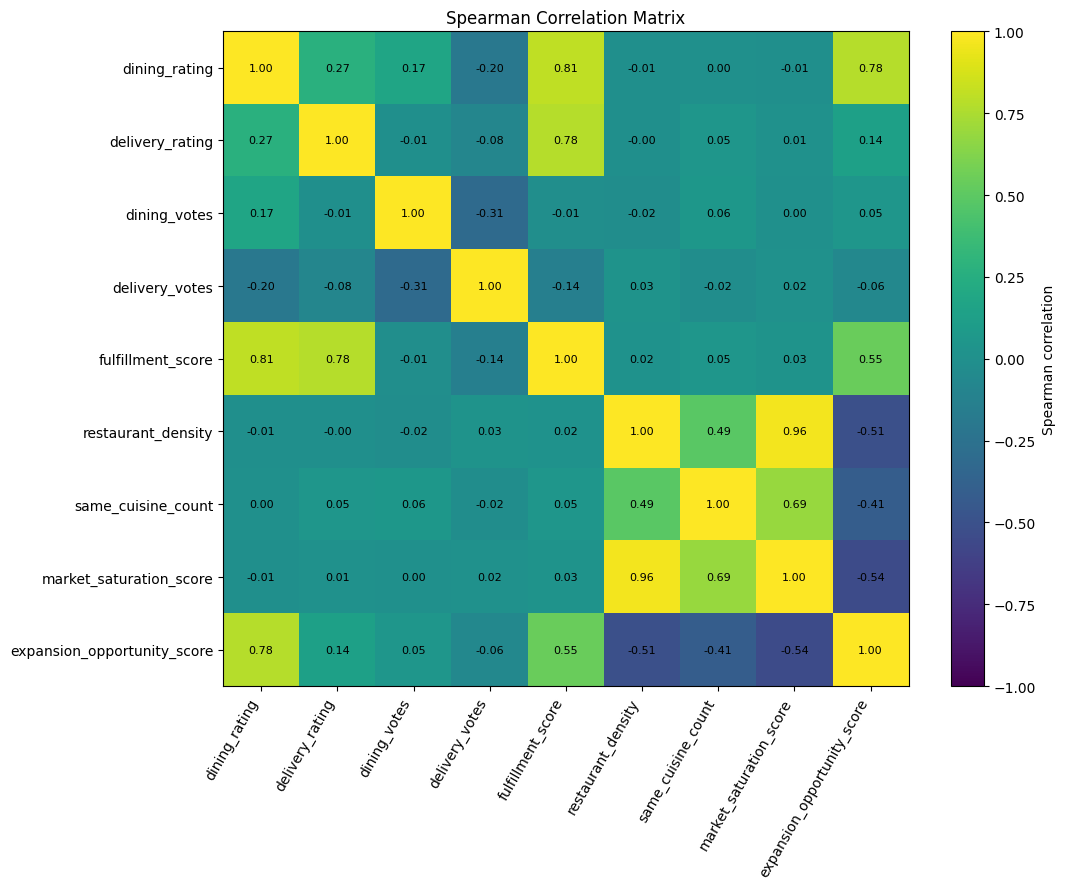

In [44]:
fig, ax = plt.subplots(
    figsize=(11, 9)
)

image = ax.imshow(
    corr.values,
    vmin=-1,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xticks(
    np.arange(
        len(corr.columns)
    )
)

ax.set_xticklabels(
    corr.columns,
    rotation=60,
    ha="right"
)

ax.set_yticks(
    np.arange(
        len(corr.index)
    )
)

ax.set_yticklabels(
    corr.index
)

ax.set_title(
    "Spearman Correlation Matrix"
)

fig.colorbar(
    image,
    ax=ax,
    label="Spearman correlation"
)

for i in range(
    corr.shape[0]
):
    for j in range(
        corr.shape[1]
    ):
        value = corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR /
    "26_spearman_correlation_heatmap.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

#### 30. Top and Bottom Expansion Opportunities

In [47]:
expansion = query_df(
    f"""
    SELECT *
    FROM {GOLD_EXPANSION}
    ORDER BY final_expansion_score DESC
    """
)

print("TOP 10")

display(
    expansion.head(10)
)

print("BOTTOM 10")

display(
    expansion.tail(10)
)

TOP 10


,city_name,locality_name,restaurant_count,avg_dining_rating,avg_delivery_rating,avg_restaurant_density,avg_same_cuisine_count,avg_saturation_score,avg_existing_expansion_score,dining_votes,delivery_votes,rating_score,engagement_score,coverage_score,saturation_penalty_score,final_expansion_score
0,Hyderabad,Nallakunta,1,4.2,3.9,1.0,1.0,0.0,0.636,697,0,0.887195,0.841463,0.570122,0.570122,0.733
1,Hyderabad,Somajiguda,1,4.2,3.8,1.0,1.0,0.0,0.679,692,0,0.887195,0.838415,0.570122,0.570122,0.732
2,Mumbai,Carter Road,1,4.5,4.3,1.0,1.0,0.0,0.661,319,0,0.990854,0.673780,0.570122,0.570122,0.722
3,Hyderabad,Meerpet,1,4.2,4.0,1.0,1.0,0.0,0.641,495,0,0.887195,0.774390,0.570122,0.570122,0.716
4,Ahmedabad,Prahlad Nagar,1,4.3,4.1,1.0,1.0,0.0,0.626,322,0,0.954268,0.676829,0.570122,0.570122,0.712
5,Delhi,Rajinder Nagar,1,4.5,4.4,1.0,1.0,0.0,0.658,227,0,0.990854,0.625000,0.570122,0.570122,0.710
6,Lucknow,Mahanagar,1,4.1,4.0,1.0,1.0,0.0,0.609,586,355,0.823171,0.807927,0.570122,0.570122,0.705
7,Mumbai,Mahalaxmi,1,4.3,4.1,1.0,1.0,0.0,0.622,265,0,0.954268,0.649390,0.570122,0.570122,0.705
8,Chennai,Thousand Lights,1,4.0,4.1,1.0,1.0,0.0,0.603,848,0,0.740854,0.890244,0.570122,0.570122,0.701
9,Pune,Jm Road,1,4.2,4.5,1.0,1.0,0.0,0.613,368,0,0.887195,0.704268,0.570122,0.570122,0.699


BOTTOM 10


,city_name,locality_name,restaurant_count,avg_dining_rating,avg_delivery_rating,avg_restaurant_density,avg_same_cuisine_count,avg_saturation_score,avg_existing_expansion_score,dining_votes,delivery_votes,rating_score,engagement_score,coverage_score,saturation_penalty_score,final_expansion_score
319,Kolkata,Sector 4,4,3.3,3.60,4.0,4.00,0.244,0.434,37,0,0.198171,0.381098,0.152439,0.073171,0.207
320,Goa,Candolim,2,NaN,NaN,2.0,1.00,0.031,0.578,0,4,0.000000,0.000000,0.365854,0.402439,0.172
321,Ahmedabad,Memnagar,2,NaN,4.10,2.0,1.00,0.031,0.558,0,724,0.000000,0.000000,0.365854,0.402439,0.172
322,Mumbai,Prabhadevi,2,NaN,4.15,2.0,1.00,0.031,0.549,0,108,0.000000,0.000000,0.365854,0.402439,0.172
323,Kolkata,Kasba,2,NaN,4.10,2.0,2.00,0.081,0.510,0,0,0.000000,0.000000,0.365854,0.304878,0.152
324,Bangalore,Wilson Garden,3,NaN,3.90,3.0,1.00,0.063,0.499,0,844,0.000000,0.000000,0.253049,0.338415,0.131
325,Jaipur,Bais Godam,3,NaN,3.87,3.0,1.00,0.063,0.515,0,1136,0.000000,0.000000,0.253049,0.338415,0.131
326,Bangalore,Frazer Town,3,NaN,4.23,3.0,1.00,0.063,0.539,0,0,0.000000,0.000000,0.253049,0.338415,0.131
327,Kolkata,Esplanade,3,NaN,3.97,3.0,1.67,0.096,0.497,0,107,0.000000,0.000000,0.253049,0.222561,0.108
328,Mumbai,Sion,4,NaN,3.90,4.0,1.50,0.119,0.545,0,1352,0.000000,0.000000,0.152439,0.192073,0.077
